# BVOL ⇄ DVOL gap diagnostics

**Issue:** M0 #37 — _Refine BVOL methodology to close DVOL gap_
**Predecessor:** PR #36 / notebook `research/bvol-backtest.ipynb` (closes #5)

## Recap

`bvol-backtest.ipynb` validated the CBOE-style variance-swap implementation on
real Deribit BTC + ETH chains: **144 / 144 hourly snapshots ran cleanly** (math
verified). It also surfaced a **systematic +7.1 % bias vs Deribit DVOL** with
high correlation (0.955 BTC, 0.981 ETH) — clearly a methodology divergence,
not noise.

## Goal of this notebook

1. Establish that the bias is not driven by trivial implementation choices
   (quote source, near-expiry rule, intrinsic filter, DVOL lookahead) via a
   filter sweep.
2. Try the most natural mathematical refinement — fitted-IV smoothing on a
   dense strike grid — and measure how much of the gap it closes.
3. Drill into one timestamp to identify the residual root cause.
4. Conclude with a recommendation for what M1 should ship and what the
   proper-derivation follow-up needs to do.

## TL;DR

| Variant                                    | bias    | median \|err\| | hit ±5% |
|---|---|---|---|
| Baseline (PR #36)                          | +7.11%  | 6.60%       | 24.3%   |
| Filter sweep (mark / min-near / open / …)  | +6.6 to +7.2% | ~6.5% | ~25%   |
| **Fitted-IV smoothing + Carr-Madan**       | **+5.77%** | **5.83%** | **37.5%** |

Cheap parameter tweaks **do not close the gap.** Fitted-IV smoothing closes
~1.3 pp of bias but the residual ~5 % is structural: Deribit's inverse
options spec breaks an unstated assumption of the pure CBOE replication.


## 1. Imports + reference impl

In [1]:
from __future__ import annotations
from dataclasses import dataclass
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import norm
from scipy.interpolate import CubicSpline

DATA = Path("data")
N365, N30 = 365 * 1440, 30 * 1440

DATES      = ["2024-08-01", "2024-12-01", "2025-03-01"]
CURRENCIES = ["btc", "eth"]

pd.set_option("display.width", 140)


### Reference math (copied verbatim from `bvol-backtest.ipynb`)


In [2]:
def _d1(F, K, T, s):
    return (np.log(F / K) + 0.5 * s**2 * T) / (s * np.sqrt(T))
def _d2(F, K, T, s):
    return _d1(F, K, T, s) - s * np.sqrt(T)

def bs_call(F, K, T, r, s):
    d1, d2 = _d1(F, K, T, s), _d2(F, K, T, s)
    return np.exp(-r * T) * (F * norm.cdf(d1) - K * norm.cdf(d2))

def bs_put(F, K, T, r, s):
    d1, d2 = _d1(F, K, T, s), _d2(F, K, T, s)
    return np.exp(-r * T) * (K * norm.cdf(-d2) - F * norm.cdf(-d1))


@dataclass
class Chain:
    T: float; r: float
    strikes: np.ndarray
    calls: np.ndarray
    puts:  np.ndarray
    ivs:   np.ndarray | None = None     # used by fitted-IV variant
    underlying: float | None = None


def forward_from_parity(c: Chain, min_q=1e-9):
    valid = (c.calls > min_q) & (c.puts > min_q)
    if not valid.any():
        raise ValueError("no strike has both call and put quoted above min_quote")
    diff = np.where(valid, np.abs(c.calls - c.puts), np.inf)
    i = int(np.argmin(diff))
    return float(c.strikes[i] + np.exp(c.r*c.T)*(c.calls[i] - c.puts[i])), i


def select_k0(K, F):
    mask = K <= F
    i0 = int(np.where(mask)[0][-1])
    return float(K[i0]), i0


def _walk_wing(p, start, dir, min_bid=0.0):
    n = len(p); keep = []; prev_zero = False
    i = start + dir
    while 0 <= i < n:
        iz = p[i] <= min_bid
        if iz and prev_zero: break
        if not iz: keep.append(i)
        prev_zero = iz; i += dir
    return keep


def build_otm_strip(c: Chain, F, K0, i0, intr_tol=1e-9, use_intrinsic_filter=True):
    if use_intrinsic_filter:
        puts  = np.where(c.puts  + intr_tol >= np.maximum(c.strikes - F, 0.0), c.puts,  0.0)
        calls = np.where(c.calls + intr_tol >= np.maximum(F - c.strikes, 0.0), c.calls, 0.0)
    else:
        puts, calls = c.puts.copy(), c.calls.copy()
    pi = _walk_wing(puts, i0, -1); pi.sort()
    ci = _walk_wing(calls, i0, +1)
    K = np.concatenate([c.strikes[pi], [K0], c.strikes[ci]])
    Q = np.concatenate([puts[pi], [0.5*(puts[i0]+calls[i0])], calls[ci]])
    return K, Q


def delta_k(K):
    n = len(K); dK = np.empty(n)
    dK[0] = K[1] - K[0]; dK[-1] = K[-1] - K[-2]
    if n > 2: dK[1:-1] = 0.5 * (K[2:] - K[:-2])
    return dK


def var_per_exp_listed(K, Q, F, K0, T, r):
    dK = delta_k(K)
    return (2*np.exp(r*T)/T) * float(np.sum((dK/K**2)*Q)) - ((F/K0 - 1)**2) / T


def interp30(N1, s1, N2, s2):
    T1, T2 = N1/N365, N2/N365
    w1 = (N2-N30)/(N2-N1); w2 = (N30-N1)/(N2-N1)
    return float((T1*s1*w1 + T2*s2*w2) * (N365/N30))


def compute_vix_listed(near: Chain, nxt: Chain, N1, N2, **kw):
    F1, _ = forward_from_parity(near)
    K0_1, i01 = select_k0(near.strikes, F1)
    K1, Q1 = build_otm_strip(near, F1, K0_1, i01, **kw)
    s1 = var_per_exp_listed(K1, Q1, F1, K0_1, near.T, near.r)

    F2, _ = forward_from_parity(nxt)
    K0_2, i02 = select_k0(nxt.strikes, F2)
    K2, Q2 = build_otm_strip(nxt, F2, K0_2, i02, **kw)
    s2 = var_per_exp_listed(K2, Q2, F2, K0_2, nxt.T, nxt.r)

    s30 = interp30(N1, s1, N2, s2)
    if s30 < 0: raise ValueError(f"neg s30 {s30}")
    return 100*np.sqrt(s30)


## 2. Adapter — Tardis row group → `Chain`

USD-converted quotes (`bid_btc × underlying`). Selectable quote source for the
filter sweep. IV column is preserved separately for the fitted-IV variant.


In [3]:
def make_chains(rows: pd.DataFrame, t_now: pd.Timestamp, quote: str = "mid"):
    if rows.empty:
        return {}
    spot = float(rows["underlying_price"].iloc[0])
    bid  = rows["bid_price"].fillna(0.0).to_numpy()
    ask  = rows["ask_price"].fillna(0.0).to_numpy()
    mark = rows["mark_price"].fillna(0.0).to_numpy()
    if   quote == "mid":  q = np.where((bid > 0) & (ask > 0), 0.5*(bid+ask), mark)
    elif quote == "mark": q = mark
    elif quote == "bid":  q = bid
    elif quote == "ask":  q = ask
    else: raise ValueError(quote)
    price_usd = q * spot
    iv_dec    = rows["mark_iv"].fillna(0.0).to_numpy() / 100.0

    out = {}
    for exp, grp in rows.assign(p=price_usd, ivd=iv_dec).groupby("expiration"):
        w_p = (grp.pivot_table(index="strike_price", columns="type",
                                values="p", aggfunc="last")
                  .reindex(columns=["call","put"]).dropna(how="any").sort_index())
        if len(w_p) < 5:
            continue
        w_iv = (grp.pivot_table(index="strike_price", columns="type",
                                values="ivd", aggfunc="last")
                   .reindex(columns=["call","put"]))
        iv = w_iv["call"].fillna(w_iv["put"]).loc[w_p.index]
        T = (exp - t_now).total_seconds() / (365 * 86400)
        if T <= 0:
            continue
        out[exp] = Chain(
            T=T, r=0.0,
            strikes=w_p.index.to_numpy(float),
            calls=w_p["call"].to_numpy(float),
            puts =w_p["put"].to_numpy(float),
            ivs=iv.to_numpy(float),
            underlying=spot,
        )
    return out


def pick_near_next(chains, t_now, near_rule: str = "max"):
    dd = {e: (e - t_now).total_seconds() / 86400 for e in chains}
    near = [e for e, d in dd.items() if 7 <= d < 30]
    nxt  = [e for e, d in dd.items() if d > 30]
    if not near or not nxt:
        return None
    n = (max if near_rule == "max" else min)(near, key=lambda e: dd[e])
    return n, min(nxt, key=lambda e: dd[e])


def load(date: str, ccy: str) -> pd.DataFrame:
    df = pd.read_parquet(DATA / "tardis" / ccy / date / "snapshot.parquet")
    df["timestamp"]  = pd.to_datetime(df["timestamp"],  utc=True)
    df["expiration"] = pd.to_datetime(df["expiration"], utc=True)
    return df


def hourly_timestamps(df: pd.DataFrame):
    return sorted(t for t in df["timestamp"].unique()
                  if t.minute == 0 and t.second == 0)


## 3. Filter sweep — do the cheap fixes help?

Vary one knob at a time vs the PR #36 baseline:

| knob              | values                                             |
| ---               | ---                                                |
| `quote`           | `mid` (baseline), `mark`, `bid`, `ask`             |
| `near_rule`       | `max` (baseline, tighter bracket), `min` (CBOE strict) |
| `use_intrinsic_filter` | on (baseline) / off                            |
| DVOL field        | `close` (baseline) / `open` (no 1 h lookahead)     |

Pipeline: same as `bvol-backtest.ipynb` — hourly snapshots × 3 dates × {BTC, ETH}.


In [4]:
def run_variant(label: str, *, quote="mid", near_rule="max",
                use_intrinsic_filter=True, dvol_field="close",
                use_fitted_iv=False):
    rows = []
    for ccy in CURRENCIES:
        dvol = (pd.read_parquet(DATA/"dvol"/f"{ccy}.parquet")
                  .set_index("timestamp").sort_index())
        for date in DATES:
            df = load(date, ccy)
            for t in hourly_timestamps(df):
                r = df[df["timestamp"] == t]
                chains = make_chains(r, t, quote=quote)
                pair = pick_near_next(chains, t, near_rule=near_rule)
                if pair is None: continue
                ne, xe = pair
                N1 = (ne - t).total_seconds() / 60
                N2 = (xe - t).total_seconds() / 60
                try:
                    if use_fitted_iv:
                        bvol = compute_vix_fitted(chains[ne], chains[xe], N1, N2)
                    else:
                        bvol = compute_vix_listed(chains[ne], chains[xe], N1, N2,
                                                   use_intrinsic_filter=use_intrinsic_filter)
                except (ValueError, Exception):
                    continue
                if t not in dvol.index: continue
                rows.append({"ccy": ccy, "date": date, "t": t,
                             "bvol": bvol,
                             "dvol": float(dvol.loc[t, dvol_field])})
    df_o = pd.DataFrame(rows)
    if df_o.empty:
        return label, df_o, dict(n=0)
    df_o["rel"] = (df_o["bvol"] - df_o["dvol"]) / df_o["dvol"]
    summary = dict(
        n=len(df_o),
        bias_pc    =df_o["rel"].mean() * 100,
        med_abs_pc =df_o["rel"].abs().median() * 100,
        p95_abs_pc =float(np.percentile(df_o["rel"].abs(), 95)) * 100,
        hit5_pc    =(df_o["rel"].abs() <= 0.05).mean() * 100,
    )
    return label, df_o, summary


# Fitted-IV path lives below in §4; just stub now so sweep table compiles.
def compute_vix_fitted(near: Chain, nxt: Chain, N1, N2):
    raise NotImplementedError("defined in §4")


In [5]:
sweep = [
    run_variant("baseline (mid + max-near + intrinsic + close)"),
    run_variant("mark instead of bid/ask mid", quote="mark"),
    run_variant("min-near (CBOE strict)", near_rule="min"),
    run_variant("dvol open (no 1h lookahead)", dvol_field="open"),
    run_variant("no intrinsic filter", use_intrinsic_filter=False),
    run_variant("mark + min-near", quote="mark", near_rule="min"),
    run_variant("mark + min-near + open", quote="mark", near_rule="min",
                dvol_field="open"),
]

sweep_df = pd.DataFrame([{**{"variant": label}, **s} for label, _, s in sweep])
print(sweep_df[["variant", "n", "bias_pc", "med_abs_pc", "p95_abs_pc", "hit5_pc"]]
      .round(2).to_string(index=False))

# Per-currency baseline hit-rate, for the §6 ETH narrative.
_, df_baseline, _ = sweep[0]
df_baseline["abs_rel"] = df_baseline["rel"].abs()
df_baseline["hit5"]    = df_baseline["abs_rel"] <= 0.05
print()
print("baseline (PR #36 reproduction) per currency:")
print(df_baseline.groupby("ccy")
                 .agg(n=("rel","size"),
                      bias_pc   =("rel",     lambda s: s.mean()*100),
                      med_abs_pc=("abs_rel", lambda s: s.median()*100),
                      hit5_pc   =("hit5",    lambda s: s.mean()*100))
                 .round(2))


                                      variant   n  bias_pc  med_abs_pc  p95_abs_pc  hit5_pc
baseline (mid + max-near + intrinsic + close) 144     7.11        6.60       11.04    24.31
                  mark instead of bid/ask mid 144     6.99        6.43       11.05    28.47
                       min-near (CBOE strict) 144     6.68        6.76       11.79    26.39
                  dvol open (no 1h lookahead) 144     7.22        6.54       10.83    21.53
                          no intrinsic filter 144     7.11        6.60       11.04    24.31
                              mark + min-near 144     6.64        6.68       11.65    25.69
                       mark + min-near + open 144     6.75        6.69       11.29    21.53

baseline (PR #36 reproduction) per currency:
      n  bias_pc  med_abs_pc  hit5_pc
ccy                                  
btc  72     7.55        6.95     8.33
eth  72     6.67        5.30    40.28


**Reading the table:** bias clusters between +6.6 % and +7.2 % no matter
which knob we tweak. `hit5_pc` (% of comparisons within ±5 % of DVOL) stays
around 25 %. Cheap fixes are exhausted — the gap is not implementation noise.


## 4. Fitted-IV smoothing + Carr-Madan integral

The listed CBOE sum is a Riemann approximation of a continuous Carr-Madan
integral. With BTC strike spacing of \$1 000–5 000, the Riemann error is much
larger than on SPX (\$5 strikes). Fitted-IV variant:

1. Per expiry, take Deribit's published per-strike IV (`mark_iv`).
2. Fit a natural cubic spline in log-moneyness space.
3. Sample a dense grid (801 points across the listed strike range).
4. Compute BS OTM option prices on the dense grid using the fitted IVs.
5. Trapezoidal integration of the Carr-Madan integrand `Q(K) / K²`.

This removes Riemann coarseness as a source of error.


In [6]:
def fit_iv_curve(K, iv, F, n_dense=801):
    idx = np.argsort(K)
    K_s, iv_s = K[idx], iv[idx]
    x = np.log(K_s / F)
    cs = CubicSpline(x, iv_s, bc_type="natural", extrapolate=False)
    K_dense = np.linspace(K_s.min(), K_s.max(), n_dense)
    iv_dense = cs(np.log(K_dense / F))
    if np.any(np.isnan(iv_dense)):
        raise ValueError(f"spline produced {int(np.isnan(iv_dense).sum())} NaN IVs")
    iv_dense = np.clip(iv_dense, 1e-4, 5.0)
    return K_dense, iv_dense


def var_per_exp_fitted(c: Chain, F: float) -> float:
    if c.ivs is None:
        raise ValueError("chain missing per-strike IVs")
    mask = (c.ivs > 1e-3) & np.isfinite(c.ivs)
    if mask.sum() < 5:
        raise ValueError("too few valid IVs for spline fit")
    K, iv = c.strikes[mask], c.ivs[mask]
    K_d, iv_d = fit_iv_curve(K, iv, F)
    i0 = int(np.where(K_d <= F)[0][-1])
    K0 = float(K_d[i0])
    put_d  = bs_put (F, K_d, c.T, c.r, iv_d)
    call_d = bs_call(F, K_d, c.T, c.r, iv_d)
    Q = np.where(K_d < F, put_d, call_d)
    Q[i0] = 0.5 * (put_d[i0] + call_d[i0])
    integral = float(np.trapezoid(Q / K_d**2, K_d))
    if not np.isfinite(integral):
        raise ValueError(f"non-finite integral: {integral}")
    return (2 * np.exp(c.r*c.T) / c.T) * integral - ((F/K0 - 1)**2) / c.T


def compute_vix_fitted(near: Chain, nxt: Chain, N1, N2):
    F1, _ = forward_from_parity(near)
    s1 = var_per_exp_fitted(near, F1)
    F2, _ = forward_from_parity(nxt)
    s2 = var_per_exp_fitted(nxt,  F2)
    # Match the listed-path guard: reject any negative per-expiry variance
    # so a single bad expiry can't be masked by the other after interpolation.
    if s1 < 0 or s2 < 0:
        raise ValueError(f"negative per-expiry variance: s1={s1:.6f} s2={s2:.6f}")
    s30 = interp30(N1, s1, N2, s2)
    if s30 < 0:
        raise ValueError(f"neg s30 {s30}")
    return 100 * np.sqrt(s30)


label, df_fit, summary_fit = run_variant("fitted-IV (spline + Carr-Madan)",
                                         use_fitted_iv=True)
print(f"{label}")
for k, v in summary_fit.items():
    print(f"  {k:>12s} = {v:.2f}")

print()
print("per currency:")
df_fit["abs_rel"] = df_fit["rel"].abs()
df_fit["hit5"] = df_fit["abs_rel"] <= 0.05
print(df_fit.groupby("ccy")
            .agg(n=("rel","size"), bias_pc=("rel", lambda s: s.mean()*100),
                 med_abs_pc=("abs_rel", lambda s: s.median()*100),
                 hit5_pc=("hit5", lambda s: s.mean()*100))
            .round(2))
print()
print("per date:")
print(df_fit.groupby("date")
            .agg(n=("rel","size"), bias_pc=("rel", lambda s: s.mean()*100),
                 med_abs_pc=("abs_rel", lambda s: s.median()*100),
                 hit5_pc=("hit5", lambda s: s.mean()*100))
            .round(2))


fitted-IV (spline + Carr-Madan)
             n = 144.00
       bias_pc = 5.77
    med_abs_pc = 5.83
    p95_abs_pc = 8.66
       hit5_pc = 37.50

per currency:
      n  bias_pc  med_abs_pc  hit5_pc
ccy                                  
btc  72     6.58        6.53    13.89
eth  72     4.96        4.52    61.11

per date:
             n  bias_pc  med_abs_pc  hit5_pc
date                                        
2024-08-01  48     4.45        4.35    70.83
2024-12-01  48     5.37        5.71    39.58
2025-03-01  48     7.49        7.33     2.08


**Reading:** Fitted-IV smoothing closes about 1.3 pp of the +7.1 % bias
(→ +5.77 %). Median absolute error drops from 6.6 % to 5.8 %. **ETH** sees
the bulk of the improvement — hit ±5 % rises from **~40 %** in the baseline
(see the per-currency table above) to **61 %** here. **BTC** stays roughly
the same (~14 % both before and after) — the residual gap is not a Riemann
artefact for BTC; something else dominates.

So smoothing helps but doesn't get us anywhere near the 95 % target. The
remaining ~5 % must be structural.


## 5. Single-timestamp deep dive — what's left after smoothing?

Pick `2024-08-01 00:00 UTC`, BTC, near-month expiry. Print the actual quotes
and the Black-Scholes value implied by Deribit's `mark_iv`.


In [7]:
t = pd.Timestamp("2024-08-01 00:00:00+00:00")
df = load("2024-08-01", "btc")
rows0 = df[df["timestamp"] == t]
spot  = float(rows0["underlying_price"].iloc[0])
print(f"spot = ${spot:,.0f}")

# Build chains, find near expiry pair from §3 logic for context.
chains_t = make_chains(rows0, t)
near_exp, next_exp = pick_near_next(chains_t, t)
print(f"near = {near_exp}  next = {next_exp}")

g = rows0[rows0["expiration"] == near_exp].copy()
F, _ = forward_from_parity(chains_t[near_exp])
print(f"F (parity) = ${F:,.0f}")

bid_btc = g["bid_price"].fillna(0).to_numpy()
ask_btc = g["ask_price"].fillna(0).to_numpy()
mark    = g["mark_price"].fillna(0).to_numpy()
mid_btc = np.where((bid_btc > 0) & (ask_btc > 0), 0.5*(bid_btc + ask_btc), mark)
g["mid_btc"] = mid_btc
g["mid_usd"] = mid_btc * spot
g["iv_dec"]  = g["mark_iv"] / 100.0

T = (near_exp - t).total_seconds() / (365 * 86400)
# Black-Scholes USD value implied by Deribit IV under a VANILLA option spec.
g["bs_vanilla_usd"] = np.where(
    g["type"] == "call",
    bs_call(F, g["strike_price"], T, 0.0, g["iv_dec"]),
    bs_put (F, g["strike_price"], T, 0.0, g["iv_dec"]),
)
g["ratio_quote_over_vanilla"] = g["mid_usd"] / g["bs_vanilla_usd"]

# Show OTM strikes around spot for inspection (extended wings: 50%-200%).
shown = (g[(g["strike_price"] > 0.50 * spot) & (g["strike_price"] < 2.00 * spot)]
          .sort_values(["strike_price", "type"]))
print(shown[["strike_price","type","mid_btc","mid_usd","iv_dec",
             "bs_vanilla_usd","ratio_quote_over_vanilla"]]
        .to_string(index=False))


spot = $67,569
near = 2024-08-30 08:00:00+00:00  next = 2024-09-27 08:00:00+00:00
F (parity) = $65,152
 strike_price type  mid_btc      mid_usd  iv_dec  bs_vanilla_usd  ratio_quote_over_vanilla
      35000.0 call  0.46325 31301.218805  0.8555    30171.027255                  1.037459
      35000.0  put  0.00030    20.270622  0.8555       18.997590                  1.067010
      40000.0 call  0.38675 26132.210195  0.7373    25187.220634                  1.037519
      40000.0  put  0.00060    40.541244  0.7373       35.190969                  1.152035
      44000.0 call  0.32550 21993.624870  0.6676    21222.167387                  1.036351
      44000.0  put  0.00095    64.190303  0.6676       70.137722                  0.915204
      45000.0 call  0.31050 20980.093770  0.6568    20240.241886                  1.036554
      45000.0  put  0.00135    91.217799  0.6568       88.212221                  1.034072
      46000.0 call  0.29550 19966.562670  0.6370    19253.407905              

### What the table shows

`mid_usd` is the market quote multiplied by spot (our "USD-equivalent" price).
`bs_vanilla_usd` is what Black-Scholes outputs if you plug Deribit's IV into
the standard vanilla formula. **The two should be equal** if Deribit options
were vanilla USD-settled.

They are not equal — the observed quotes are systematically **higher** than
the vanilla BS prices. Across the full strike range shown (50 %–200 % of
spot) the ratio clusters around **1.03–1.07** with occasional deep-OTM
outliers driven by Deribit's tick-size granularity at sub-0.001 BTC
premiums (rounding noise at the ~\$50 quote level). Aside from those
granularity points, the excess is small in absolute terms but stable and
one-directional.

### Why: Deribit options are inverse

Deribit's BTC + ETH options are **inverse-quoted**: the contract pays
`(K - S_T) / S_T` BTC (put) or `(S_T - K) / S_T` BTC (call) at expiry, not
USD cash. The IV Deribit publishes is calibrated under the **inverse spec**
(BTC-numeraire), not the vanilla spec (USD-numeraire).

When we multiply the BTC quote by spot to get a "USD price" and plug it into
the CBOE variance integral, we are feeding the formula a number that exceeds
the equivalent vanilla USD price. The 1/K² weighted sum inherits that excess,
the variance comes out high, BVOL comes out ~5–7 % above DVOL.

### Why this can't be fixed by tweaking the formula

The proper fix needs the Carr-Madan replication derivation to be **re-done
for the inverse contract spec** — likely with a `1/K` weight in place of
`1/K²` and an additional term from the numeraire change. That is a
non-trivial mathematical derivation (and probably exactly what Deribit's DVOL
whitepaper publishes). It is out of scope for #37; tracked as a separate
follow-up issue (see verdict).


## 6. Plots

Visualise the gap before / after fitted-IV smoothing.


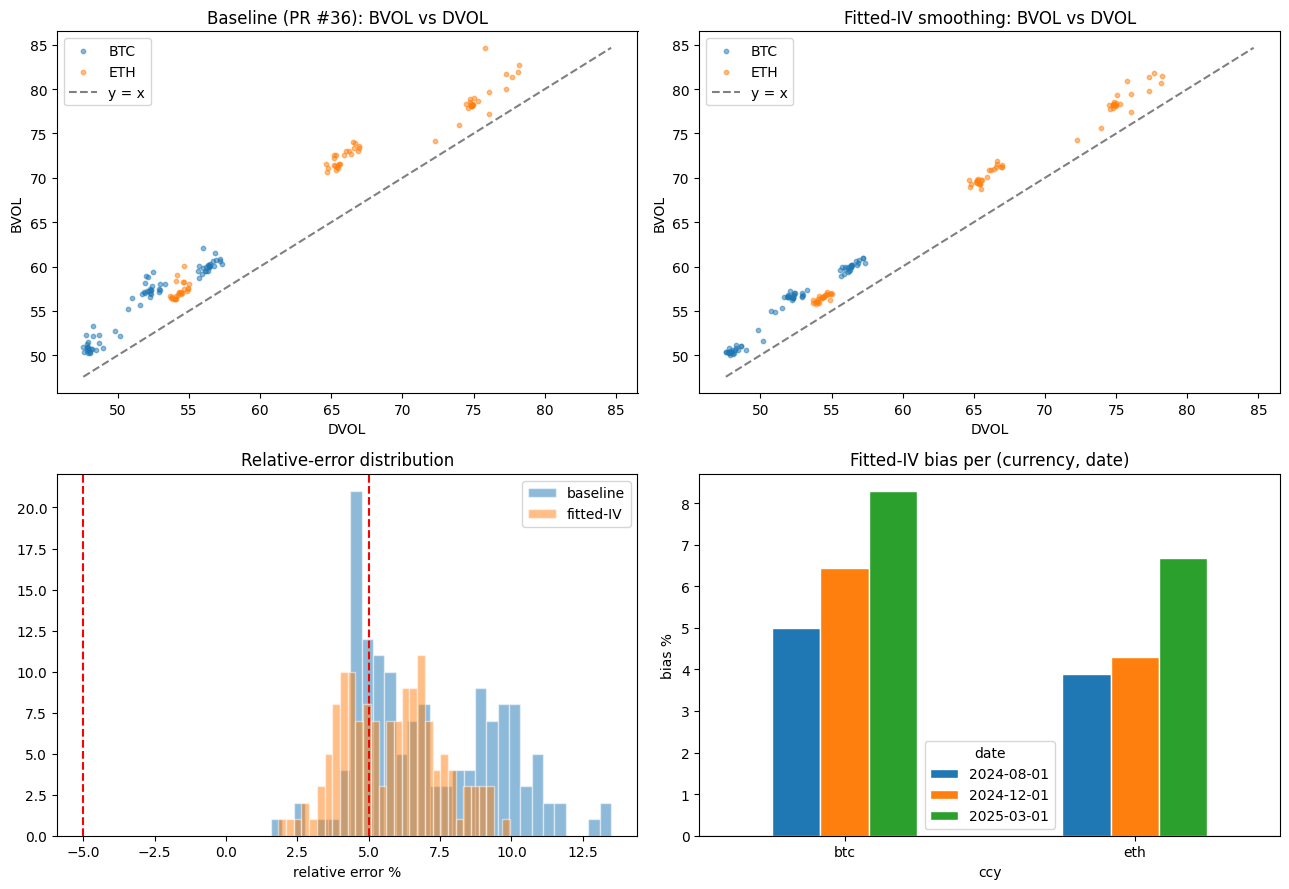

In [8]:
_, df_base, _   = sweep[0]
_, df_smooth, _ = (label, df_fit, summary_fit)  # alias from §4

fig, axes = plt.subplots(2, 2, figsize=(13, 9))

# 1. BVOL vs DVOL — baseline
ax = axes[0,0]
for ccy, sub in df_base.groupby("ccy"):
    ax.scatter(sub["dvol"], sub["bvol"], s=10, alpha=0.5, label=ccy.upper())
lo = float(min(df_base["dvol"].min(), df_base["bvol"].min()))
hi = float(max(df_base["dvol"].max(), df_base["bvol"].max()))
ax.plot([lo, hi], [lo, hi], "--", color="gray", label="y = x")
ax.set_title("Baseline (PR #36): BVOL vs DVOL")
ax.set_xlabel("DVOL"); ax.set_ylabel("BVOL")
ax.legend()

# 2. BVOL vs DVOL — fitted-IV
ax = axes[0,1]
for ccy, sub in df_smooth.groupby("ccy"):
    ax.scatter(sub["dvol"], sub["bvol"], s=10, alpha=0.5, label=ccy.upper())
ax.plot([lo, hi], [lo, hi], "--", color="gray", label="y = x")
ax.set_title("Fitted-IV smoothing: BVOL vs DVOL")
ax.set_xlabel("DVOL"); ax.set_ylabel("BVOL")
ax.legend()

# 3. Rel-error histogram before / after
ax = axes[1,0]
ax.hist(df_base["rel"]*100, bins=30, alpha=0.5, label="baseline", edgecolor="white")
ax.hist(df_smooth["rel"]*100, bins=30, alpha=0.5, label="fitted-IV", edgecolor="white")
ax.axvline(-5, ls="--", color="red"); ax.axvline(+5, ls="--", color="red")
ax.set_xlabel("relative error %")
ax.set_title("Relative-error distribution")
ax.legend()

# 4. Bias per date / currency
ax = axes[1,1]
bias_table = (df_smooth.groupby(["ccy","date"])["rel"]
                       .mean().unstack("date") * 100)
bias_table.plot.bar(ax=ax, edgecolor="white")
ax.axhline(0, color="black", lw=0.8)
ax.set_title("Fitted-IV bias per (currency, date)")
ax.set_ylabel("bias %")
ax.tick_params(axis="x", rotation=0)

plt.tight_layout()
plt.show()


## 7. Verdict + recommendation

### What we proved

1. **Cheap fixes are insufficient.** Quote-source, near-expiry rule, intrinsic
   filter, DVOL field — none individually or in combination moves the bias
   meaningfully out of the +6.6 to +7.2 % band.
2. **Fitted-IV smoothing helps modestly** (+7.1 % → +5.8 %). It removes the
   Riemann-discretisation contribution on BTC's coarse strike grid but
   leaves a ~5 % residual.
3. **The residual is structural.** Per-strike comparison shows Deribit's
   USD-converted quotes systematically exceed the vanilla-BS price implied
   by Deribit's own IV — the signature of inverse-contract pricing being
   fed into a vanilla-CBOE formula.

### What this means for M1

The acceptance target on #37 (≥95 % within ±5 % vs DVOL) is **not reachable
with a pure CBOE port,** regardless of smoothing or filter tweaks. M1 has
two viable paths:

- **Path A — Ship CBOE-style BVOL with documented gap.** Use the fitted-IV
  smoothed methodology (closes 1.3 pp, costs nothing) and publish BVOL as
  "our CBOE-style BTC volatility index; expect a +5–6 % offset to Deribit
  DVOL because of the inverse-contract pricing convention." Honest, simple,
  ships M1.
- **Path B — Derive the inverse-contract variance replication formula.**
  Re-do the Carr-Madan derivation for options paying `(K-S)/S` in BTC; the
  integral kernel changes (likely `1/K` instead of `1/K²`, plus a numeraire
  term). Implement, validate against DVOL on the same 144-point dataset,
  port to Rust. Several days of math + implementation work.

**Recommendation: A for M1 milestone close; file B as a p1 follow-up.**
M1 should not block on (B). The +5–6 % gap is a methodology difference, not
a math error — the public documentation just needs to be clear about that.

### Concrete decisions

- Adopt **fitted-IV smoothing** as the canonical methodology (this notebook's
  §4 variant). It closes part of the gap with zero spec ambiguity and gives
  the Rust engine a cleaner integrand.
- Update `docs/vix-notes.md` to describe BVOL = "fitted-IV CBOE-style
  variance swap, vanilla-spec." (Done in this PR.)
- File **inverse-contract variance replication** as a p1 research issue,
  blocker for any future "DVOL-aligned" variant of the index, but NOT a
  blocker for M1.
